# Medical Cost Analysis System

## Project Overview

This project analyzes a medical insurance dataset to discover the factors that influence medical charges. Using Python, Pandas, Matplotlib, and Seaborn, the data is cleaned, explored, and visualized to provide meaningful business insights that can support decision-making in the healthcare insurance industry.

# Import Required Libraries

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



# Load the Dataset

In [14]:
sns.set_style("whitegrid")

df = pd.read_csv("../data/insurance.csv")

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# Data Exploration

In [ ]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (1338, 7)

Columns:
Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

Data Types:
age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

Missing Values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [ ]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
df.sample(5)

,age,sex,bmi,children,smoker,region,charges
1297,28,female,26.510,2,no,southeast,4340.44090
432,42,male,26.900,0,no,southwest,5969.72300
1011,43,male,20.130,2,yes,southeast,18767.73770
392,48,male,31.445,1,no,northeast,8964.06055
482,18,female,31.350,0,no,southeast,1622.18850


# Data Visualization

## 1. Age Distribution

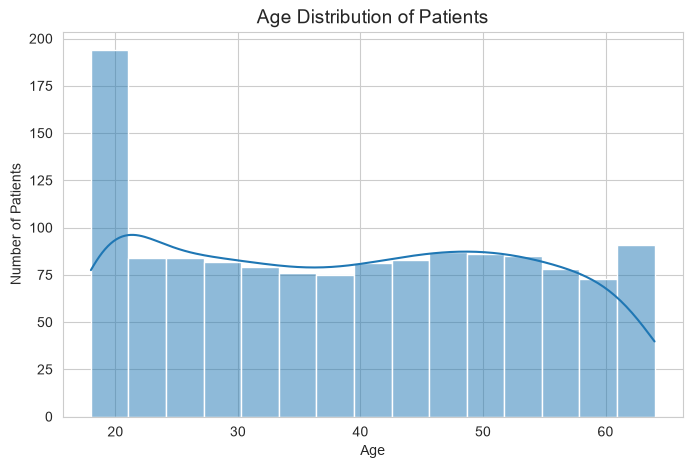

In [5]:

plt.figure(figsize=(8,5))

sns.histplot(df["age"], bins=15, kde=True)

plt.title("Age Distribution of Patients", fontsize=14)
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.savefig("../images/histogram.png", dpi=300, bbox_inches="tight")

plt.show()

## 2. Age vs Medical Charges

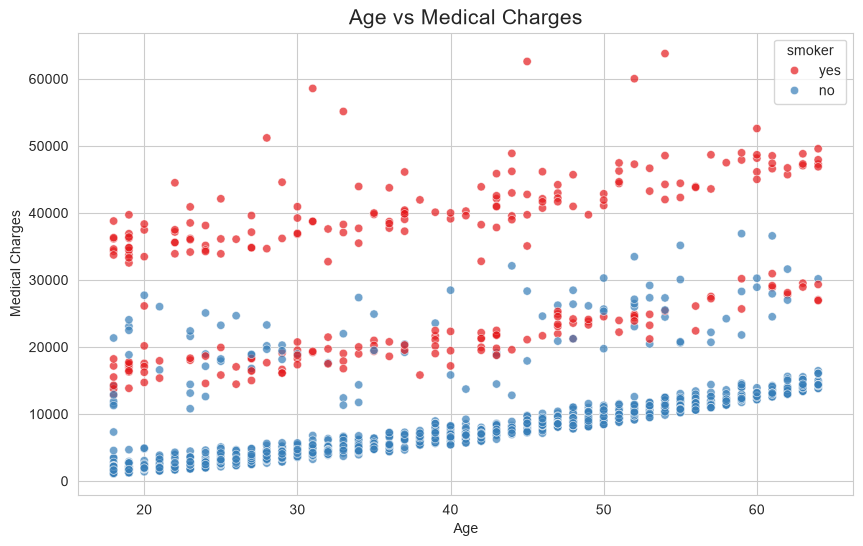

In [7]:

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="age",
    y="charges",
    hue="smoker",
    palette="Set1",
    alpha=0.7
)

plt.title("Age vs Medical Charges", fontsize=15)
plt.xlabel("Age")
plt.ylabel("Medical Charges")

plt.savefig("../images/scatter_plot.png", dpi=300, bbox_inches="tight")

plt.show()

## 3. Distribution of Medical Charges

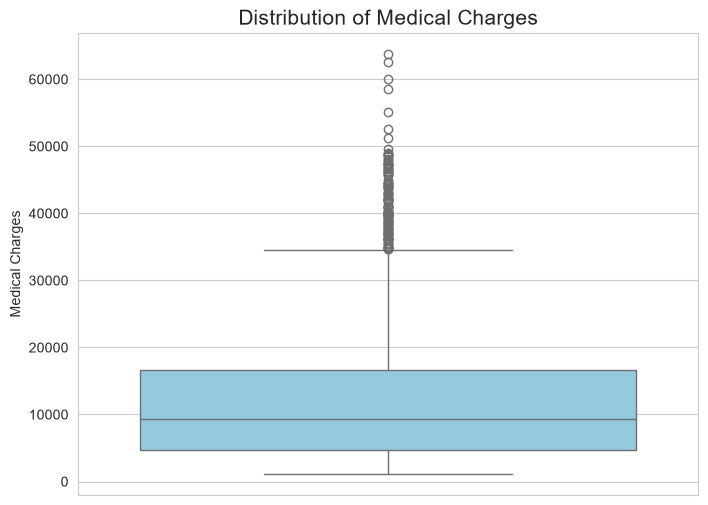

In [8]:

plt.figure(figsize=(8,6))

sns.boxplot(
    y=df["charges"],
    color="skyblue"
)

plt.title("Distribution of Medical Charges", fontsize=15)
plt.ylabel("Medical Charges")

plt.savefig("../images/box_plot.png", dpi=300, bbox_inches="tight")

plt.show()

## 4. Smoker Distribution

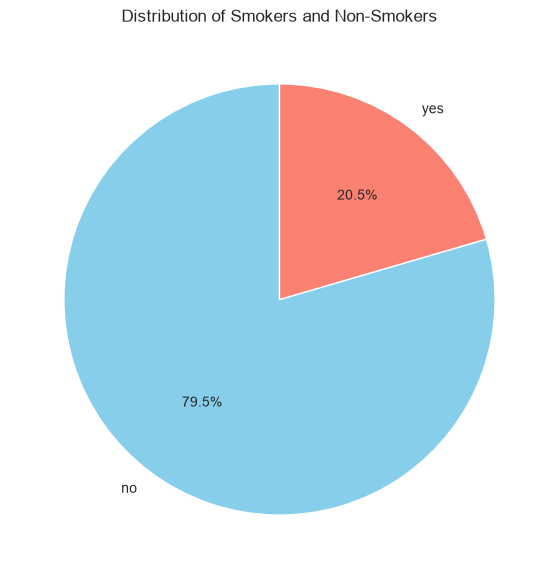

In [9]:

plt.figure(figsize=(7,7))

df["smoker"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90,
    colors=["skyblue", "salmon"]
)

plt.title("Distribution of Smokers and Non-Smokers")
plt.ylabel("")

plt.savefig("../images/pie_chart.png", dpi=300, bbox_inches="tight")

plt.show()

## 5. Correlation Matrix

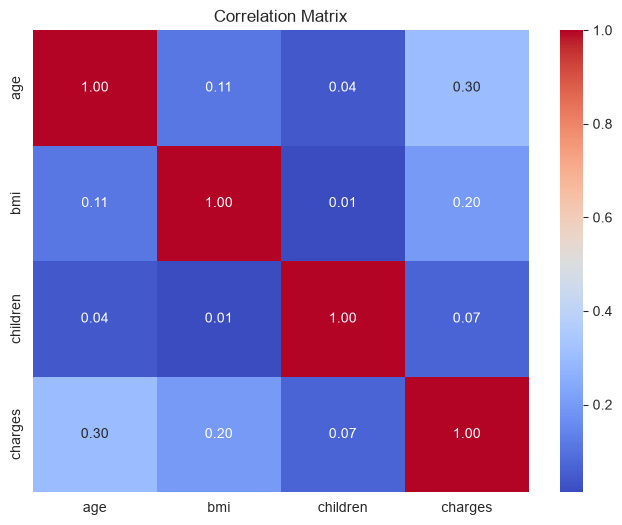

In [10]:

plt.figure(figsize=(8,6))

numeric_df = df.select_dtypes(include="number")

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.savefig("../images/heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

## 6. Average Medical Charges by Smoking Status

<Axes: xlabel='smoker', ylabel='charges'>

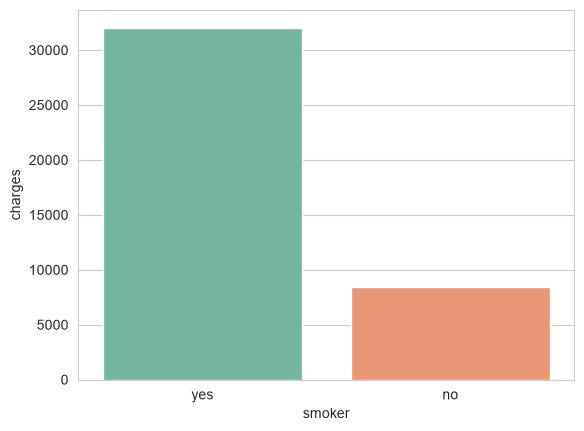

In [12]:
sns.barplot(
    data=df,
    x="smoker",
    y="charges",
    hue="smoker",
    estimator="mean",
    errorbar=None,
    palette="Set2",
    legend=False
)

# Business Insights

In [15]:

print("Average Medical Charge: ${:.2f}".format(df["charges"].mean()))

print("\nHighest Medical Charge: ${:.2f}".format(df["charges"].max()))

print("\nLowest Medical Charge: ${:.2f}".format(df["charges"].min()))

Average Medical Charge: $13270.42

Highest Medical Charge: $63770.43

Lowest Medical Charge: $1121.87


In [16]:

smoker_avg = df[df["smoker"] == "yes"]["charges"].mean()
non_smoker_avg = df[df["smoker"] == "no"]["charges"].mean()

print(f"Average charge for smokers: ${smoker_avg:.2f}")
print(f"Average charge for non-smokers: ${non_smoker_avg:.2f}")

Average charge for smokers: $32050.23
Average charge for non-smokers: $8434.27


In [ ]:

region_avg = df.groupby("region")["charges"].mean().sort_values(ascending=False)

print(region_avg)

region
southeast    14735.411438
northeast    13406.384516
northwest    12417.575374
southwest    12346.937377
Name: charges, dtype: float64


In [18]:

highest = df.loc[df["charges"].idxmax()]

highest

age                  54
sex              female
bmi               47.41
children              0
smoker              yes
region        southeast
charges     63770.42801
Name: 543, dtype: object

# Conclusion

This project analyzed a medical insurance dataset using Python.

The analysis revealed that smoking status has the strongest impact on medical charges, while age and BMI also contribute significantly.

The visualizations and statistical analysis transform raw healthcare data into meaningful insights that can support better business decisions in the insurance industry.

- Build an interactive Streamlit dashboard.
- Predict medical charges using Machine Learning.
- Connect the system to a SQL database.
- Deploy the project as a web application.